In [3]:
import sys
from pathlib import Path
import torch
import yaml
import numpy as np
import matplotlib.pyplot as plt
from typing import Dict, Any, List, Tuple
import warnings

from spd.utils import get_device
warnings.filterwarnings('ignore')

# Add the project root to path so we can import spd modules
project_root = Path().resolve().parent
sys.path.append(str(project_root))

from spd.experiments.tms.models import TMSModel, TMSModelConfig
from spd.data_utils import DatasetGeneratedDataLoader, SparseFeatureDataset
from spd.models.component_model import ComponentModel


device = get_device()
print(f"Using device: {device}")
torch.set_grad_enabled(False)

Using device: cuda


In [4]:
from spd.models.component_model import ComponentModel
from spd.experiments.resid_mlp.resid_mlp_dataset import ResidualMLPDataset

from spd.plotting import plot_mask_vals

MODEL_PATH = "/afs/cs.stanford.edu/u/nathu/code/apd/spd/experiments/resid_mlp/out/randrecon1.00e+00_p2.00e+00_lpsp1.00e-05_m100_sd1_lr2.00e-03_bs2048_gtgate_mlp_ft100_lay1_resid1000_mlp50_20250618_181826_677/model_30000.pth"
# Load the decomposition model
comp_model, config, _ = ComponentModel.from_pretrained(MODEL_PATH)
comp_model.to(device)
target_model = comp_model.model


dataset = ResidualMLPDataset(
    n_features=target_model.config.n_features,
    feature_probability=config.task_config.feature_probability,
    device=device,
    calc_labels=False,  # Our labels will be the output of the target model
    label_type=None,
    act_fn_name=None,
    label_fn_seed=None,
    label_coeffs=None,
    data_generation_type=config.task_config.data_generation_type,
    synced_inputs=None,
)

2025-06-23 14:19:05 - INFO - Downloaded checkpoint from /sailhome/nathu/code/apd/wandb/92pa1z14/files/resid_mlp.pth


In [5]:
data_loader = DatasetGeneratedDataLoader(
    dataset=dataset,
    batch_size=1000,
    shuffle=False,)

In [8]:
from tqdm import tqdm
from typing import List, Any
from torch.utils.data import DataLoader
from jaxtyping import Float, Int
from torch import Tensor
import torch

from spd.models.component_utils import calc_component_acts, calc_masks
from spd.utils import extract_batch_data

def calc_jaccard_index(co_occurrence_matrix: Tensor, marginal_counts: Tensor) -> Tensor:
    """
    Calculate the Jaccard index for each component based on co-occurrence matrix and marginal counts.
    Jaccard index = |A ∩ B| / |A ∪ B|
    """
    intersection = co_occurrence_matrix
    union = marginal_counts.unsqueeze(0) + marginal_counts.unsqueeze(1) - intersection
    jaccard_index = intersection / union
    jaccard_index[union == 0] = 0.0  # Handle division by zero
    return jaccard_index

@torch.no_grad()
def collect_coactivations(
    comp_model: ComponentModel,
    data_loader: DataLoader[Int[Tensor, "..."]] | DataLoader[tuple[Float[Tensor, "..."], Float[Tensor, "..."]]],
    module_groups: List[List[str]],  # e.g., [["layers.0.mlp"], ["layers.1.attn", "layers.1.mlp"]],
    n_samples: int = 10000, #number of samples to collect for co-activation
    activation_threshold: float = 0.5, # mask threshold for a component to be considered active
    device: str = 'cuda' if torch.cuda.is_available() else 'cpu',
) -> Dict[str, Any]:
    # 1. Setup phase - FIXED: use comp_model not model
    components = {k.removeprefix("components.").replace("-", "."): v
                for k, v in comp_model.components.items()}
    gates = {k.removeprefix("gates.").replace("-", "."): v
            for k, v in comp_model.gates.items()}

    # Build module_slices for each group
    results = {}
    for group_idx, modules in enumerate(module_groups):
        # Calculate total components and slices within group
        group_total_m = sum(components[mod].m for mod in modules)  # FIXED: no need to convert, already dots
        co_matrix = torch.zeros(group_total_m, group_total_m, device=device)
        marginals = torch.zeros(group_total_m, device=device)

        # Build slice mapping
        module_slices = {}
        start_idx = 0
        for mod in modules:
            m = components[mod].m  # FIXED: use mod directly
            module_slices[mod] = slice(start_idx, start_idx + m)
            start_idx += m

        results[f"group_{group_idx}"] = {
            "co_occurrence_matrix": co_matrix,
            "marginal_counts": marginals,
            "module_slices": module_slices,
            "modules": modules
        }
    # Data processing loop - exact same pattern as optimize()
    samples_processed = 0
    data_iter = iter(data_loader)

    with tqdm(total=n_samples, desc="Collecting coactivations", unit="samples") as pbar:
        while samples_processed < n_samples:
            try:
                batch_item = next(data_iter)
                batch = extract_batch_data(batch_item)
            except StopIteration:
                data_iter = iter(data_loader)
                batch_item = next(data_iter)
                batch = extract_batch_data(batch_item)
            batch = batch.to(device)

            target_out, pre_weight_acts = comp_model.forward_with_pre_forward_cache_hooks(
                batch, module_names=list(set(mod for group in module_groups for mod in group))
            )
            As = {module_name: components[module_name].A  # FIXED: use module_name directly
                for module_name in pre_weight_acts.keys()}

            target_component_acts = calc_component_acts(pre_weight_acts=pre_weight_acts, As=As)

            masks, _ = calc_masks(
                gates=gates, target_component_acts=target_component_acts, detach_inputs=True
            )

            # Process each group
            for group_idx, modules in enumerate(module_groups):
                # Concatenate masks within group
                group_masks = torch.cat([masks[mod] for mod in modules], dim=-1)  # [batch, group_m]

                # Apply threshold
                active_mask = group_masks > activation_threshold  # [batch, group_m]

                # Accumulate co-occurrences and marginals
                results[f"group_{group_idx}"]["co_occurrence_matrix"] += torch.einsum('bi,bj->ij', active_mask.float(), active_mask.float())
                results[f"group_{group_idx}"]["marginal_counts"] += active_mask.sum(dim=0)
            batch_size = batch.size(0)
            samples_processed += batch_size
            pbar.update(batch_size)
    # Add metadata.additoinal_metrics
    for group_key in results:
        results[group_key]["total_samples"] = samples_processed
        results[group_key]["activation_threshold"] = activation_threshold
        results[group_key]["jaccard"] = calc_jaccard_index(results[group_key]["co_occurrence_matrix"], results[group_key]["marginal_counts"])

    return results

In [9]:
results = collect_coactivations(
    comp_model=comp_model,
    data_loader=data_loader,
    module_groups= [['layers.0.mlp_in'],['layers.0.mlp_out'], ['layers.0.mlp_in', 'layers.0.mlp_out']],
    n_samples=10000,
    activation_threshold=0.5,
)

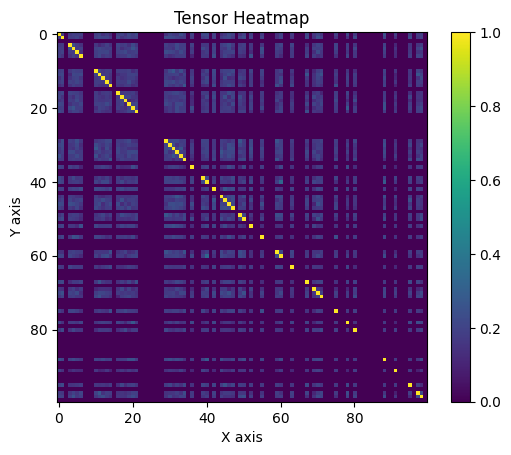

In [14]:
import torch
import matplotlib.pyplot as plt
# Basic heatmap
plt.imshow(results['group_1']['jaccard'].cpu().numpy(), cmap='viridis')
plt.colorbar()


plt.title('Tensor Heatmap')
plt.xlabel('X axis')
plt.ylabel('Y axis')
plt.show()